In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt

Ensure to run file "RF_Initial_Feature_Engineering.py" in path 2b_feature_engineering prior to this notebook to populate featureset.

In [4]:
df = pd.read_parquet("../../../1_download_data/model_ready/flights_model_ready.parquet")
df.head()


,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,prev_day_failure_origin,is_morning_peak,is_evening_peak
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1,0,0
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1,0,0
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,1,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,1,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,1,0,0


In [5]:
df.shape

(14539250, 69)

In [6]:
df.isnull().sum().sort_values(ascending=False).head(20)

Tail_Number       51887
relh              15364
relh_std          15364
CRSElapsedTime        7
CRSArrTime            0
ArrTimeBlk            0
DistanceGroup         0
year                  0
target                0
gust                  0
date                  0
dep_hour              0
tmpf                  0
vsby                  0
sknt                  0
p01i                  0
DepTimeBlk            0
FlightDate            0
month_sin             0
DayOfWeek_num         0
dtype: int64

In [10]:
import sys
from pathlib import Path

# Get the root project directory (two levels up from the notebook)
project_root = Path.cwd().parents[1]  # notebooks/ → project root
scripts_path = project_root / "scripts"
sys.path.append(str(scripts_path))

from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [11]:

def sample_and_split(
    df,
    output_dir="../1_download_data/model_ready/sampled_splits",
    total_sample=700_000,
    max_origin_frac=0.05,
    max_region_frac=0.30,
    test_size=0.2,
    random_state=42,
    target_col="target"
):
    """
    Sample a dataframe with balanced months, optional origin/region caps,
    stratified by target, then split into train/test and return X/y splits.
    
    Returns:
    --------
    X_train, X_test, y_train, y_test
    """
    
    df = df.copy()
    
    # -----------------------------
    # CHECK REQUIRED COLUMNS
    # -----------------------------
    required_cols = ["FlightDate", target_col]
    missing_required = [c for c in required_cols if c not in df.columns]
    if missing_required:
        raise ValueError(f"Missing required columns: {missing_required}")
    
    # -----------------------------
    # Ensure FlightDate is datetime
    # -----------------------------
    df["FlightDate"] = pd.to_datetime(df["FlightDate"])
    df["month"] = df["FlightDate"].dt.to_period("M").astype(str)
    
    # -----------------------------
    # STEP 1: BALANCE MONTHS
    # -----------------------------
    n_months = df["month"].nunique()
    rows_per_month = total_sample // n_months
    month_samples = []
    for m, g in df.groupby("month"):
        month_samples.append(
            g.sample(n=min(len(g), rows_per_month), random_state=random_state)
        )
    month_balanced = pd.concat(month_samples, ignore_index=True)
    
    # -----------------------------
    # STEP 2: CAP ORIGIN DOMINANCE
    # -----------------------------
    if "Origin" in month_balanced.columns:
        origin_cap = int(len(month_balanced) * max_origin_frac)
        origin_balanced = (
            month_balanced
            .groupby("Origin", group_keys=False)
            .apply(lambda x: x.sample(n=min(len(x), origin_cap), random_state=random_state))
        )
    else:
        origin_balanced = month_balanced.copy()
    
    # -----------------------------
    # STEP 2.5: CAP REGION DOMINANCE
    # -----------------------------
    if "OriginState" in origin_balanced.columns:
        state_to_region = {
            "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
            "NH": "Northeast", "RI": "Northeast", "VT": "Northeast",
            "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",
            "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest",
            "WI": "Midwest", "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
            "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",
            "DE": "South", "FL": "South", "GA": "South", "MD": "South",
            "NC": "South", "SC": "South", "VA": "South", "WV": "South",
            "AL": "South", "KY": "South", "MS": "South", "TN": "South",
            "AR": "South", "LA": "South", "OK": "South", "TX": "South",
            "AZ": "West", "CO": "West", "ID": "West", "MT": "West",
            "NV": "West", "NM": "West", "UT": "West", "WY": "West",
            "AK": "West", "CA": "West", "HI": "West", "OR": "West",
            "WA": "West"
        }
        origin_balanced["OriginState"] = origin_balanced["OriginState"].str.upper()
        origin_balanced["OriginRegion"] = origin_balanced["OriginState"].map(state_to_region)
        
        region_cap = int(len(origin_balanced) * max_region_frac)
        region_balanced = (
            origin_balanced
            .groupby("OriginRegion", group_keys=False)
            .apply(lambda x: x.sample(n=min(len(x), region_cap), random_state=random_state))
        )
    else:
        region_balanced = origin_balanced.copy()
    
    # -----------------------------
    # STEP 3: STRATIFY TARGET
    # -----------------------------
    n_classes = region_balanced[target_col].nunique()
    rows_per_class = len(region_balanced) // n_classes
    final_sample = (
        region_balanced
        .groupby(target_col, group_keys=False)
        .apply(lambda x: x.sample(n=min(len(x), rows_per_class), random_state=random_state))
    )
    
    # -----------------------------
    # STEP 4: SPLIT TRAIN/TEST
    # -----------------------------
    train_df, test_df = train_test_split(
        final_sample,
        test_size=test_size,
        stratify=final_sample[target_col],
        random_state=random_state
    )
    
    # -----------------------------
    # STEP 5: CREATE X/y
    # -----------------------------
    feature_cols = [c for c in final_sample.columns if c != target_col]
    
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    
    # -----------------------------
    # STEP 6: SAVE FILES (optional)
    # -----------------------------
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    train_df.to_parquet(output_dir / "train.parquet", index=False)
    test_df.to_parquet(output_dir / "test.parquet", index=False)
    
    # -----------------------------
    # STEP 7: PRINT CHECKS
    # -----------------------------
    print("Train:", train_df.shape)
    print("Test:", test_df.shape)
    
    print("\nTrain target distribution:")
    print(y_train.value_counts(normalize=True))
    
    print("\nTest target distribution:")
    print(y_test.value_counts(normalize=True))
    
    if "OriginRegion" in final_sample.columns:
        print("\nRegion distribution:")
        print(final_sample["OriginRegion"].value_counts(normalize=True))
    
    print("\nDate ranges:")
    print("Train:", train_df["FlightDate"].min(), "→", train_df["FlightDate"].max())
    print("Test :", test_df["FlightDate"].min(), "→", test_df["FlightDate"].max())
    
    return X_train, X_test, y_train, y_test

In [12]:
X_train, X_test, y_train, y_test = sample_and_split(
    df,
    total_sample=500_000,
    max_origin_frac=0.05,
    max_region_frac=0.3,
    test_size=0.2,
    output_dir="../../../1_download_data/model_ready/sampled_splits",
    random_state=42
)

/tmp/ipykernel_398/3936447638.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), origin_cap), random_state=random_state))
/tmp/ipykernel_398/3936447638.py:88: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), region_cap), random_state=random_state))
/tmp/ipykernel_398/3936447638.py:101: DeprecationWarning: DataFrameGroupBy.apply o

Train: (179519, 71)
Test: (44880, 71)

Train target distribution:
target
On time      0.611790
Delayed      0.352837
Cancelled    0.035372
Name: proportion, dtype: float64

Test target distribution:
target
On time      0.611787
Delayed      0.352852
Cancelled    0.035361
Name: proportion, dtype: float64

Region distribution:
OriginRegion
South        0.338977
West         0.334066
Northeast    0.177724
Midwest      0.149234
Name: proportion, dtype: float64

Date ranges:
Train: 2018-01-01 00:00:00 → 2022-07-30 00:00:00
Test : 2018-01-01 00:00:00 → 2022-07-30 00:00:00


In [13]:
# train_df = pd.read_parquet("../../data/model_ready/sampled_splits/train.parquet")
# test_df = pd.read_parquet("../../data/model_ready/sampled_splits/test.parquet")
# print(f"train shape: {train_df.shape}")
# print(f"test shape: {test_df.shape}")


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Random Forest Model Baseline

Features based off of EDA:
- Airline
- DeptTimeBlk
- DistanceGroup
- Month
- Dep_Hour
- Weather
- DayofWeek

In [15]:
FEATURES = ["Quarter", "Month", "DayofMonth", "DayOfWeek", "dep_hour", "DepTimeBlk",
    "Airline", "Origin", "Dest", "Distance", "DistanceGroup",
    "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

TARGET = "target"


In [17]:
# Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

numeric_features = [
    "Quarter", "Month", "DayofMonth", "dep_hour",
    "Distance", "tmpf", "vsby", "sknt", "p01i", "relh", "gust"
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)



In [18]:
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


In [19]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])


In [20]:
# Convert categorical columns to string (needed for OneHotEncoder)
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

# # Fill numeric NaNs with 0
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)

# Optional: fill categorical NaNs with "missing"
for col in categorical_features:
    X_train[col] = X_train[col].fillna("missing")
    X_test[col]  = X_test[col].fillna("missing")


In [21]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup',
                                                   'DayOfWeek']),
                                                 ('num', 'passthrough',
                                                  ['Quarter', 'Month',
                                                   'DayofMonth', 'dep_hour',
                                                   'Distance', 'tmpf', 'vsby',
                                                   'sknt', 'p01i', 'relh',
                                                   'gust'])])),
                ('rf',
                 RandomForestClassifier(max_depth=15, n_estimators=80,
                                        n_jobs=-1, random_state=42))])

In [22]:
# Predictions
y_pred = pipeline.predict(X_test)

# Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)



Classification Report:

              precision    recall  f1-score   support

   Cancelled      1.000     0.009     0.019      1587
     Delayed      0.645     0.120     0.202     15836
     On time      0.635     0.969     0.767     27457

    accuracy                          0.636     44880
   macro avg      0.760     0.366     0.329     44880
weighted avg      0.651     0.636     0.541     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.009452  0.125394  0.865154
Delayed     0.000000  0.119727  0.880273
On time     0.000000  0.030812  0.969188


Test Accuracy: 0.636

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled         15      199     1373
Delayed            0     1896    13940
On time            0      846    26611

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.009452  0.125394  0.865154
Delayed     0.000000  0.119727  0.880273
On time     0.000000  0.030812  0.969188


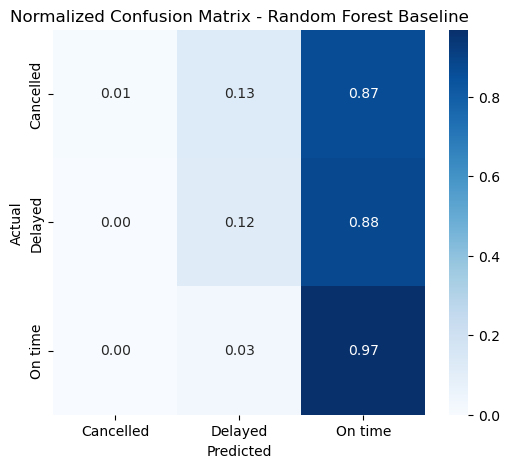


Classification Report:
              precision    recall  f1-score   support

   Cancelled      1.000     0.009     0.019      1587
     Delayed      0.645     0.120     0.202     15836
     On time      0.635     0.969     0.767     27457

    accuracy                          0.636     44880
   macro avg      0.760     0.366     0.329     44880
weighted avg      0.651     0.636     0.541     44880



In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test)
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))


Given that the class is imbalanced, a dummy classifier model who would predict all "On time" would give us a 61% accuracy with this training dataset. This baseline model performed at a 63.6% accuracy, meaning this is slightly better than a dummy model. 

From these stats, we can see that:
- the model almost never predicts cancellations, but when it does it is correct. (1.0 precision for cancellations)
- But out of the 1587 only .009% were found, which means the model is bad for predicting cancellations

- For the delays, it also misses most delays with only finding about .120 % of the delayed flights

- For the on time flights, the model predicts on time for almost everything. But this can be problematic because it won't really be able to predict any calcellations or delays if it only predicts on time. 


The classifier effectively learned that predicting “on time” is the safest strategy for maximizing overall correctness. As a result, it rarely predicts cancellations or delays. This behavior explains the high recall for on-time flights and the extremely low recall for the other categories.

The Random Forest classifier achieved an overall accuracy of 63.6%. However, a deeper analysis of class-level metrics reveals that the model is heavily biased toward predicting flights as on time. While recall for on-time flights is very high (96.9%), the model performs poorly in identifying cancelled and delayed flights, with recall values of 0.9% and 12% respectively. This indicates that the classifier frequently misses disruption events, which are often the most operationally important outcomes.

Although the model’s accuracy appears reasonable, accuracy is not an appropriate metric for this problem due to strong class imbalance. Since the majority of flights are on time, a model could predict every flight as on time and still achieve over 60% accuracy. Therefore, metrics such as recall and F1-score provide a more meaningful evaluation of performance, particularly for minority classes like cancellations.

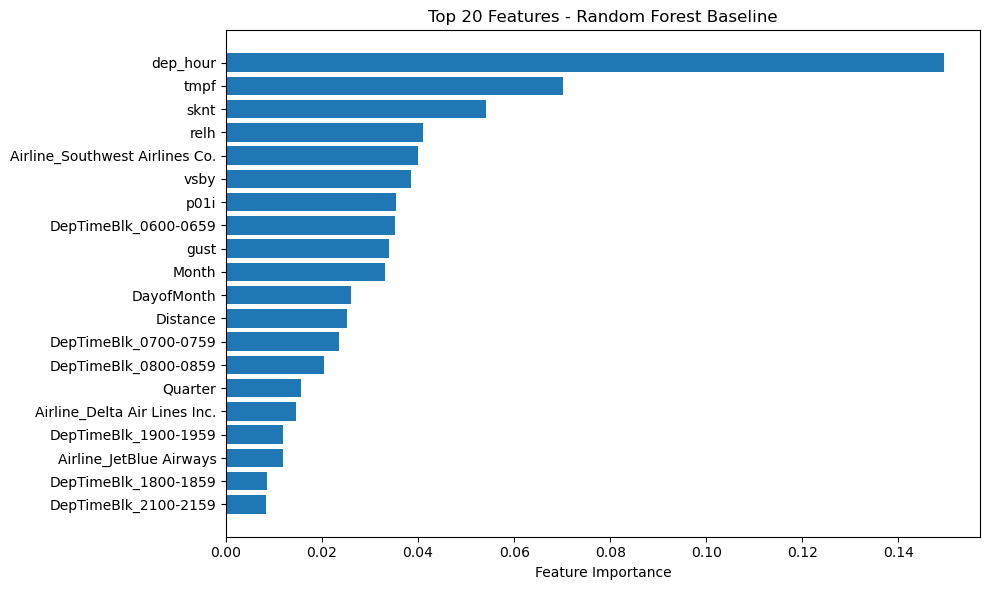

In [24]:
# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()
